---
title: "Functions, Loops, and Training the Network"
description: ""
subtitle: "5: Forward and Predict Functions"
engine: Jupyter
#jupyter: pytorch
title-block-banner: true
freeze: auto

execute:
    eval: true

author:
  - name: "Dr. Atle E. Rimehaug"

format:
  html: default
  ipynb: default
format-links: false
---

## Setup

### Import Libraries

In [1]:
import torch
from torch import nn

from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt

### Generate Data

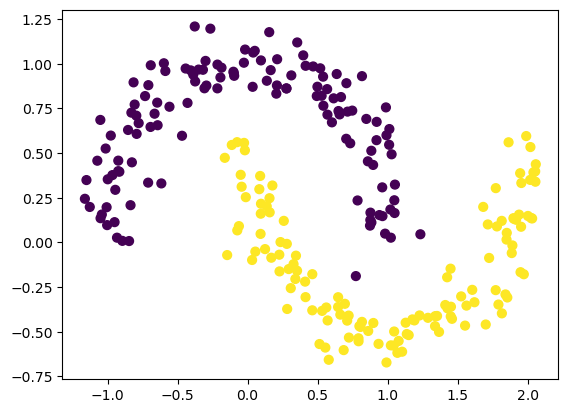

In [2]:
X, y = make_moons(256, noise=0.1)

df = pd.DataFrame({'x0': X[:, 0], 'x1': X[:,1], 'y': y})
# Create 2D numpy array from x0 and x1 columns
X_orig = df[['x0', 'x1']].to_numpy()

# Create a 1D numpy array from the y column
y_orig = df['y'].to_numpy()

plt.scatter(X_orig[:,0], X_orig[:,1], s = 40, c=y_orig)

In [3]:
# Convert the 2D points to a tensor
X = torch.tensor(X_orig, dtype = torch.float32)

# Convert labels to long integer tensor
y = torch.from_numpy(y_orig).type(torch.LongTensor)

## Section 1: Functions and For Loops

| Code | Description |
| --- | --- |
| `for letter in ["a", "b", "c"]:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(letter)` | Print every `letter` in the list `["a", "b", "c"]`|
| `for i in range(5):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 0 and 5 (not including 5)|
| `for i in range(2, 7):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 2 and 7 (not including 7)|
| `for i in range(1, 10, 2):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every **second** number `i` between 1 and 10 (not including 10)|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(x_i)` | Print every element `x_i` in the collection `x`|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `for y_i in y`: <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; `print(x_i, y_i)` | Print every element `x_i` and `y_i` in the collections `x` and `y`|
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |

::: {#exm-}
Create a function named `add` that takes in two variables `a` and `b` and returns their sum.
:::

In [4]:
def fun(a, b):
    output = a + b
    return output

::: {#exr-}
Create a function named `subtract` that takes in two variables `a` and `b` and subtracts b from a. The function should return the result.
:::

In [5]:
def subtract(a, b):
    output = a - b
    return output

::: {#exr-}
Write a for loop that prints the numbers **0** to **9**.
:::

::: {#sol-}
:::

In [6]:
for num in range(9):
    print(num)

0
1
2
3
4
5
6
7
8


::: {#exr-}
Write a for loop that prints the numbers **5** to **10**.
:::

::: {#sol-}
:::

In [7]:
for i in range(5,10):
    print(i)

5
6
7
8
9


::: {#exr-}
Write a for loop that counts from **0** to **100** in steps of **10**.
:::

::: {#sol-}
:::

In [8]:
for j in range(0,100,10):
    print(j)

0
10
20
30
40
50
60
70
80
90


::: {#exr-}
Use a loop to print all `fruits` and `colors`, for example `banana is yellow"`.
:::

::: {#sol-}
:::

In [9]:
fruits = ["banana", "orange", "cherry"]
colors= ["yellow", "orange", "green"];

for fruit in fruits:
    for color in colors:
        print(fruit+' is '+color)

banana is yellow
banana is orange
banana is green
orange is yellow
orange is orange
orange is green
cherry is yellow
cherry is orange
cherry is green


::: {#exm-}
Write a loop that calculates the square of each element in `numbers` and stores the result in a new list called `squared_numbers`. Display the `squared_numbers` list at the end to check that it is correct.
:::

In [10]:
numbers = [4, 6, 12, 50]

squared_numbers = []

for i in range(len(numbers)):
    num_squared = numbers[i]**2
    squared_numbers.append(num_squared)

squared_numbers

[16, 36, 144, 2500]

::: {#exr-}
Write a loop that multiplies each element in the list `numbers` by 4 and store the results in a new list called `multiplied_numbers`. Display `multiplied_numbers` to check that it is correct.
:::

::: {#sol-}
:::

In [11]:
numbers = [4, 6, 12, 50]

multiplied_numbers = []
for num in numbers:
    mult_number = 4*num

    multiplied_numbers.append(mult_number)

multiplied_numbers

[16, 24, 48, 200]

## Section 2: Train the Network

| Code | Description |
| --- | --- |
| `def sum_input(a,b)` <br> &nbsp;&nbsp;&nbsp;&nbsp; `output = a+b` <br> &nbsp;&nbsp;&nbsp;&nbsp;  `return output` | Creates a function `sum_input` that takes two variables `a` and `b` as input and returns the sum of them. |

In [15]:
net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

# select subset of data
X_samples = X
y_samples = y

optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

loss_function = nn.CrossEntropyLoss()

In [16]:
train_losses = []
num_epochs = 1000

for epoch in range(num_epochs):
    optimizer.zero_grad()

    output = net(X_samples)

    loss = loss_function(output, y_samples)

    train_losses.append(loss.item())

    loss.backward()

    optimizer.step()

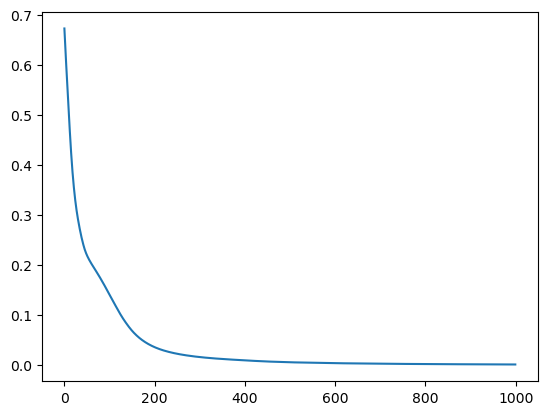

In [17]:
plt.plot(train_losses)